In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
y_test = np.load('../results/y_test.npy')
y_pred_linreg = np.load('../results/y_pred_linreg.npy')
y_pred_nn = np.load('../results/y_pred_nn.npy')

print("Files loaded successfully!")

Files loaded successfully!


In [3]:
os.makedirs('../results/plots', exist_ok=True)

print("Plots folder ready!")

Plots folder ready!


In [6]:
print("y_test shape:", y_test.shape)
print("y_pred_linreg shape:", y_pred_linreg.shape)
print("y_pred_nn shape:", y_pred_nn.shape)


y_test shape: (3194,)
y_pred_linreg shape: (15967,)
y_pred_nn shape: (15967, 1)


In [8]:
from sklearn.linear_model import Ridge
import numpy as np
import sys
sys.path.append('../src')
from neural_net import NeuralNetworkScratch

# Load training and test data
X_train = np.load('../results/X_train.npy')
y_train = np.load('../results/y_train.npy')
X_test = np.load('../results/X_test.npy')
y_test = np.load('../results/y_test.npy')

# Train best Linear Regression model (alpha=10 from grid search)
model_lr = Ridge(alpha=10)
model_lr.fit(X_train, y_train)
y_pred_linreg = model_lr.predict(X_test)
np.save('../results/y_pred_linreg.npy', y_pred_linreg)

# Train Neural Network model
model_nn = NeuralNetworkScratch(input_size=X_train.shape[1], learning_rate=0.0001)
model_nn.fit(X_train, y_train, epochs=30)
y_pred_nn = model_nn.predict(X_test)
np.save('../results/y_pred_nn.npy', y_pred_nn)

print("✅ Correct predictions regenerated and saved!")


✅ Correct predictions regenerated and saved!


In [9]:
y_test = np.load('../results/y_test.npy')
y_pred_linreg = np.load('../results/y_pred_linreg.npy')
y_pred_nn = np.load('../results/y_pred_nn.npy')

print("y_test shape:", y_test.shape)
print("y_pred_linreg shape:", y_pred_linreg.shape)
print("y_pred_nn shape:", y_pred_nn.shape)


y_test shape: (3194,)
y_pred_linreg shape: (3194,)
y_pred_nn shape: (3194, 1)


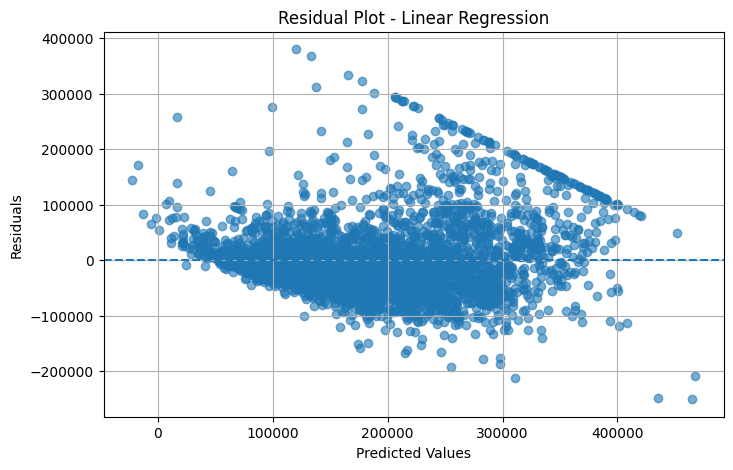

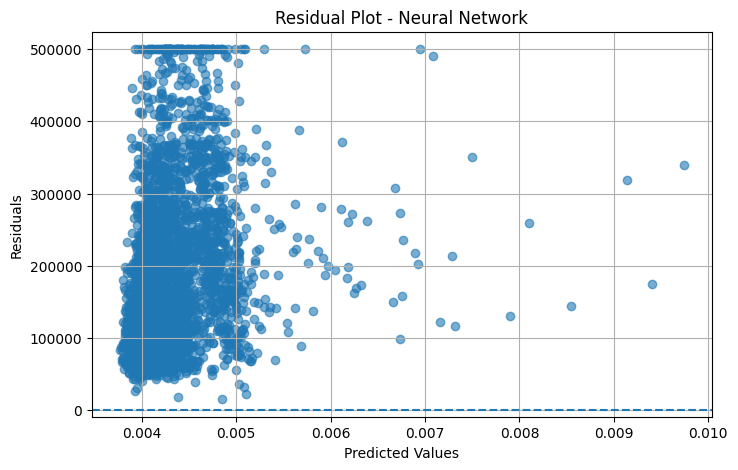

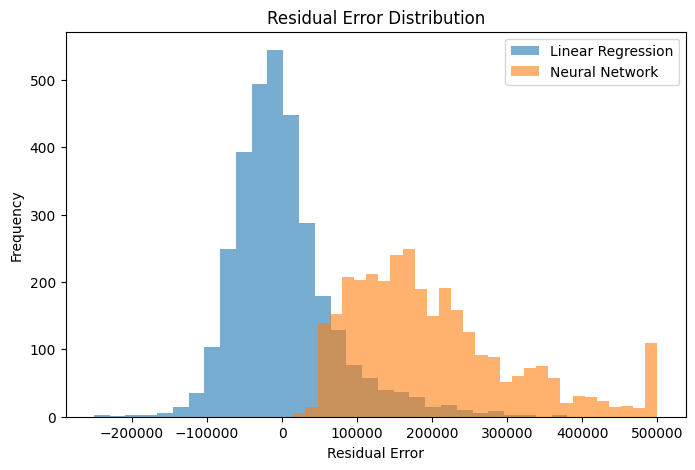

✅ Member 3 Visualization Completed


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Reload correct test and prediction files
y_test = np.load('../results/y_test.npy')
y_pred_linreg = np.load('../results/y_pred_linreg.npy')
y_pred_nn = np.load('../results/y_pred_nn.npy')

# Ensure same shape
y_test_flat = y_test.reshape(-1)
y_pred_linreg_flat = y_pred_linreg.reshape(-1)
y_pred_nn_flat = y_pred_nn.reshape(-1)

# Compute residuals
residuals_lr = y_test_flat - y_pred_linreg_flat
residuals_nn = y_test_flat - y_pred_nn_flat

# Plot residuals - Linear Regression
plt.figure(figsize=(8,5))
plt.scatter(y_pred_linreg_flat, residuals_lr, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')
plt.grid(True)
plt.savefig('../results/plots/residual_plot_linreg.png')
plt.show()

# Plot residuals - Neural Network
plt.figure(figsize=(8,5))
plt.scatter(y_pred_nn_flat, residuals_nn, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Neural Network')
plt.grid(True)
plt.savefig('../results/plots/residual_plot_nn.png')
plt.show()

# Comparison histogram
plt.figure(figsize=(8,5))
plt.hist(residuals_lr, bins=30, alpha=0.6, label='Linear Regression')
plt.hist(residuals_nn, bins=30, alpha=0.6, label='Neural Network')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.title('Residual Error Distribution')
plt.legend()
plt.savefig('../results/plots/residual_comparison.png')
plt.show()

print("✅ Member 3 Visualization Completed")


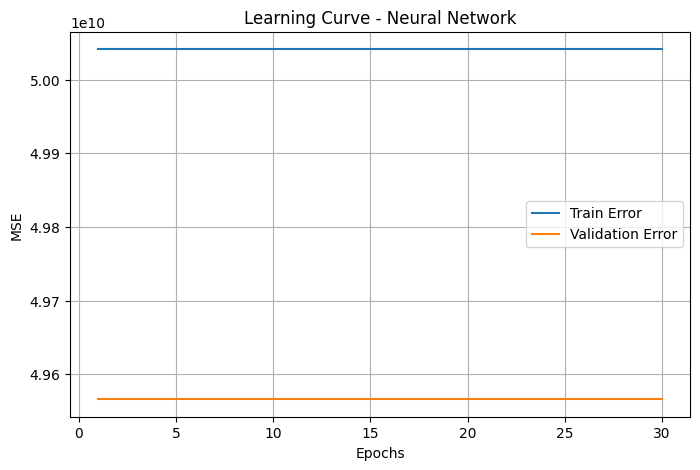

✅ Learning curve plot saved successfully!


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import sys
sys.path.append('../src')
from neural_net import NeuralNetworkScratch

# Load scaled training data
X = np.load('../results/X_train.npy')
y = np.load('../results/y_train.npy')

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

epochs = 30
train_errors, val_errors = [], []

model = NeuralNetworkScratch(input_size=X.shape[1], learning_rate=0.0001)

for epoch in range(1, epochs+1):
    model.fit(X_train, y_train, epochs=1)
    y_train_pred = model.predict(X_train).flatten()
    y_val_pred = model.predict(X_val).flatten()
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    train_errors.append(train_mse)
    val_errors.append(val_mse)

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_errors, label='Train Error')
plt.plot(range(1, epochs+1), val_errors, label='Validation Error')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Learning Curve - Neural Network')
plt.legend()
plt.grid(True)
plt.savefig('../results/plots/learning_curve_nn.png')
plt.show()

print("✅ Learning curve plot saved successfully!")
